# Federated Learning: Parameter Sweeps Analysis

In [12]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

cwd = Path.cwd()
if (cwd / 'runs').exists():
    base_dir = cwd / 'runs'
elif cwd.name == 'runs':
    base_dir = cwd
else:
    base_dir = cwd / 'runs'

plot_dir = base_dir / 'plots'
plot_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(plot_dir / name, dpi=200, bbox_inches='tight')
    print(f"Saved plot: {plot_dir / name}")

## 1. Data Loading Helper Functions

In [ ]:
def load_global_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the global metrics (like accuracy per round)."""
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv' # Fallback
    
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    return None

def load_comm_costs(run_path: Path):
    """Loads communication costs."""
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    """Loads the total run time in seconds."""
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return 0.0
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    return float(row['value'].iloc[0]) if not row.empty else 0.0

def comm_to_mb(comm_df):
    """Converts communication costs from bytes/parameters to Megabytes."""
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / (1024**2)

## 2. Generic Plotting Functions

In [ ]:
def plot_evolution_metric(experiments_dict, metric='accuracy', title='Model Comparison', filename='evolution.png'):
    """Plots a line chart of a given metric (e.g., accuracy) over communication rounds."""
    plt.figure(figsize=(10, 6))
    cm = plt.get_cmap('tab10')
    linestyles = ['-', '--', '-.', ':']
    
    plotted_any = False
    
    for i, (path, label) in enumerate(experiments_dict.items()):
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            color = cm(i % 10)
            l_style = linestyles[i % len(linestyles)]
            
            plt.plot(df['round'], df[metric], 
                     color=color, linestyle=l_style, linewidth=2, label=str(label))
            plotted_any = True
        else:
            print(f"⚠️ Warning: Could not load metric '{metric}' for '{label}' at {path}")
            
    if plotted_any:
        plt.title(title, fontsize=14)
        plt.xlabel('Communication Round', fontsize=12)
        plt.ylabel(metric.capitalize(), fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_fig(filename)
        plt.show()
    else:
        print("No data available to plot.")

def plot_cost_summary(experiments_dict, title='Cost Summary', filename='costs.png'):
    """Plots a dual-axis bar chart comparing Time (seconds) and Comm Costs (MB)."""
    times = []
    comms = []
    valid_labels = []
    
    for path, label in experiments_dict.items():
        p = Path(path)
        if not p.exists():
            print(f"⚠️ Warning: Path not found: {p}")
            continue
            
        times.append(load_run_time(p))
        comms.append(comm_to_mb(load_comm_costs(p)))
        valid_labels.append(str(label))
        
    if not times:
        print("No data to plot for costs.")
        return

    x = np.arange(len(valid_labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(max(8, len(valid_labels) * 1.5), 6))

    # Time (Left Y-Axis)
    color1 = '#E76F51' # Orange/Red
    ax1.set_xlabel('Experiment Configuration', fontsize=12)
    ax1.set_ylabel('Total Time (s)', color=color1, fontsize=12)
    rects1 = ax1.bar(x - width/2, times, width, label='Time (s)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Add time values on top of bars
    for bar in rects1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}s', 
                 ha='center', va='bottom', fontsize=10, color=color1)

    # Communication (Right Y-Axis)
    ax2 = ax1.twinx()  
    color2 = '#2A9D8F'
    ax2.set_ylabel('Total Communication (MB)', color=color2, fontsize=12)  
    rects2 = ax2.bar(x + width/2, comms, width, label='Comm (MB)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    for bar in rects2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', 
                 ha='center', va='bottom', fontsize=10, color=color2)

    ax1.set_xticks(x)
    ax1.set_xticklabels(valid_labels, rotation=45, ha="right")
    plt.title(title, fontsize=14)
    fig.tight_layout()  
    save_fig(filename)
    plt.show()

## 3. Define the Experiments to Compare

In [ ]:
# MLP CLIENT RATION & LOCAL EPOCHS

mlp_epochs_experiments = {
    base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_5_epoch": 5,
    base_dir / "lab_2_tabular_MLP_experiment_10_epoch": "10 (Base)", 
    base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_15_epoch": 15,
    base_dir / "local_epochs" / "lab_2_tabular_MLP_experiment_20_epoch": 20,
}

mlp_ratio_experiments = {
    base_dir / "client_ratio" / "lab_2_tabular_MLP_experiment_ratio_25": "25%",
    base_dir / "client_ratio" / "lab_2_tabular_MLP_experiment_ratio_50": "50%",
    base_dir / "lab_2_tabular_MLP_experiment_10_epoch": "100% (Base)" 
}

# LOGISTIC REGRESSION CLIENT RATION & LOCAL EPOCHS
logreg_epochs_experiments = {
    base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_5_epoch": 5,
    base_dir / "lab_2_tabular_LogReg_experiment_10_epoch": "10 (Base)",
    base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_15_epoch": 15,
    base_dir / "local_epochs" / "lab_2_tabular_LogReg_experiment_20_epoch": 20
}

logreg_ratio_experiments = {
    base_dir / "client_ratio" / "lab_2_tabular_LogReg_experiment_ratio_25": "25%",
    base_dir / "client_ratio" / "lab_2_tabular_LogReg_experiment_ratio_50": "50%",
    base_dir / "lab_2_tabular_LogReg_experiment_10_epoch": "100% (Base)" 
}

## 4. Generate the Plots!
Execute the cells below to generate all the comparisons dynamically.

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/mlp_epochs_accuracy.png


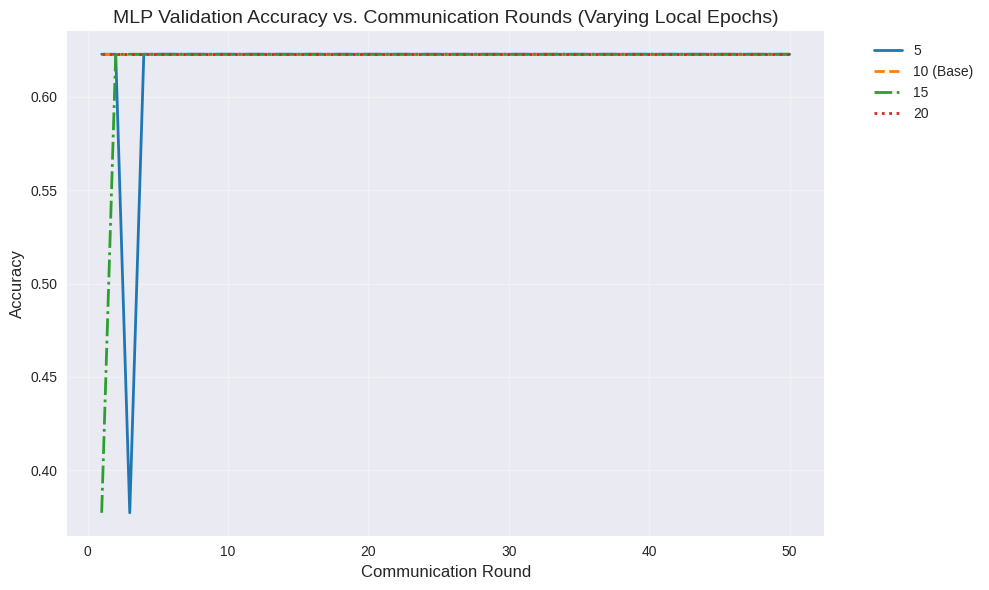

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/mlp_epochs_costs.png


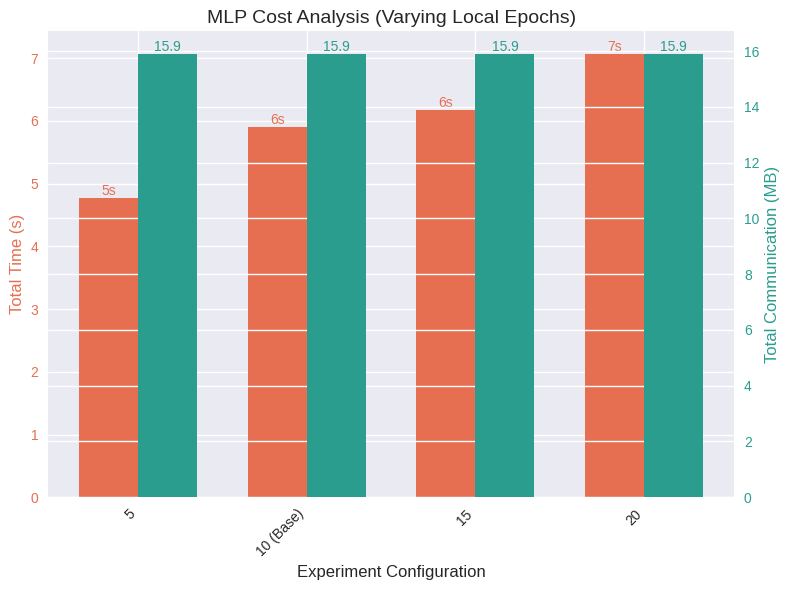

In [5]:
# MLP Local Epochs Analysis
plot_evolution_metric(mlp_epochs_experiments, metric='accuracy', 
                      title='MLP Validation Accuracy vs. Communication Rounds (Varying Local Epochs)', 
                      filename='mlp_epochs_accuracy.png')

plot_cost_summary(mlp_epochs_experiments, 
                  title='MLP Cost Analysis (Varying Local Epochs)', 
                  filename='mlp_epochs_costs.png')

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/mlp_ratio_accuracy.png


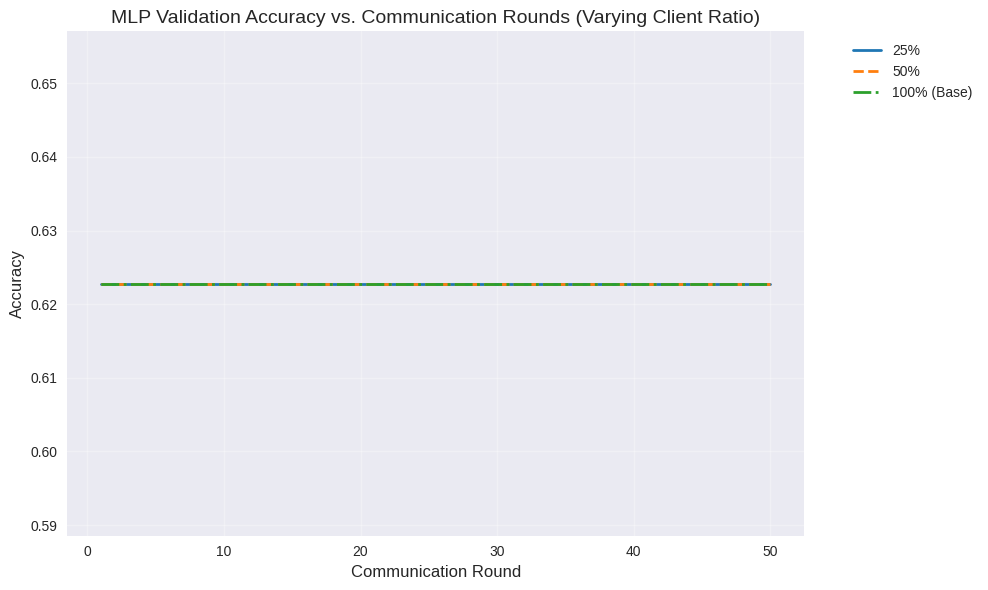

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/mlp_ratio_costs.png


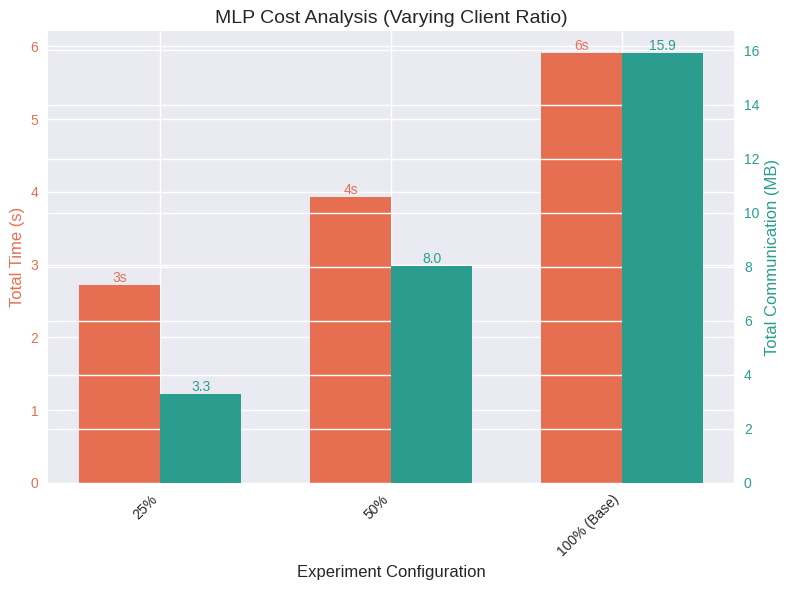

In [6]:
# MLP Client Ratio Analysis
plot_evolution_metric(mlp_ratio_experiments, metric='accuracy', 
                      title='MLP Validation Accuracy vs. Communication Rounds (Varying Client Ratio)', 
                      filename='mlp_ratio_accuracy.png')

plot_cost_summary(mlp_ratio_experiments, 
                  title='MLP Cost Analysis (Varying Client Ratio)', 
                  filename='mlp_ratio_costs.png')

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/logreg_epochs_accuracy.png


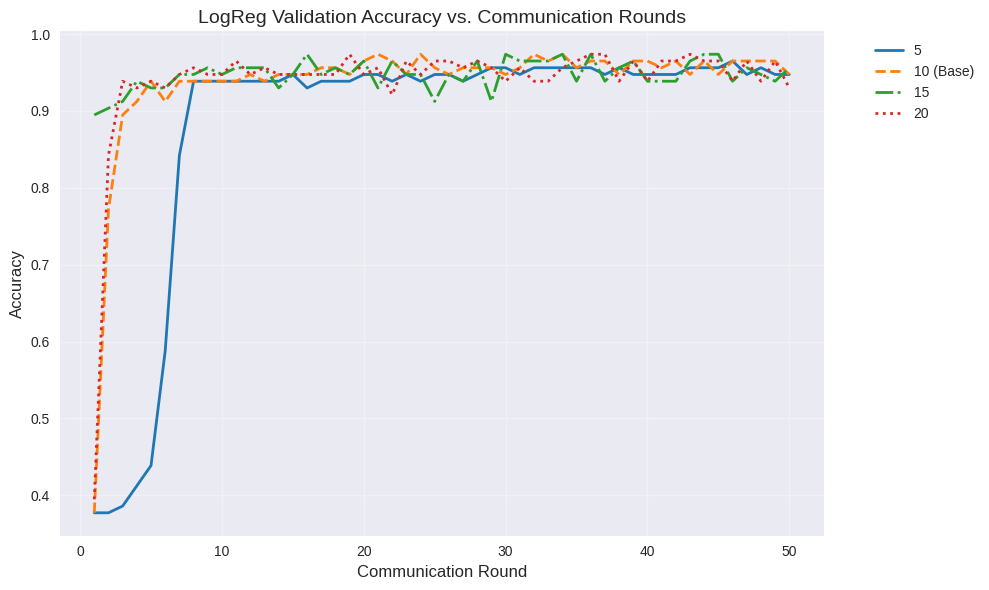

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/logreg_epochs_costs.png


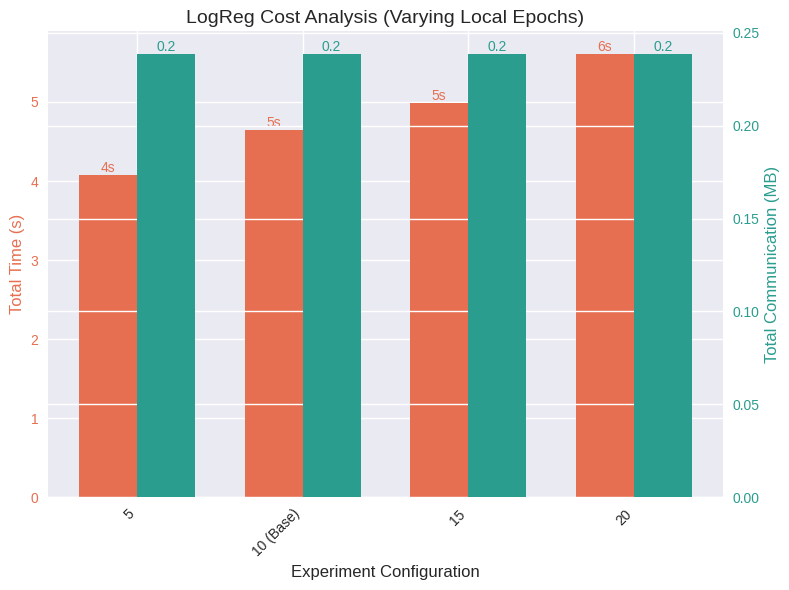

In [7]:
# LogReg Local Epochs Analysis
plot_evolution_metric(logreg_epochs_experiments, metric='accuracy', 
                      title='LogReg Validation Accuracy vs. Communication Rounds', 
                      filename='logreg_epochs_accuracy.png')

plot_cost_summary(logreg_epochs_experiments, 
                  title='LogReg Cost Analysis (Varying Local Epochs)', 
                  filename='logreg_epochs_costs.png')

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/logreg_ratio_accuracy.png


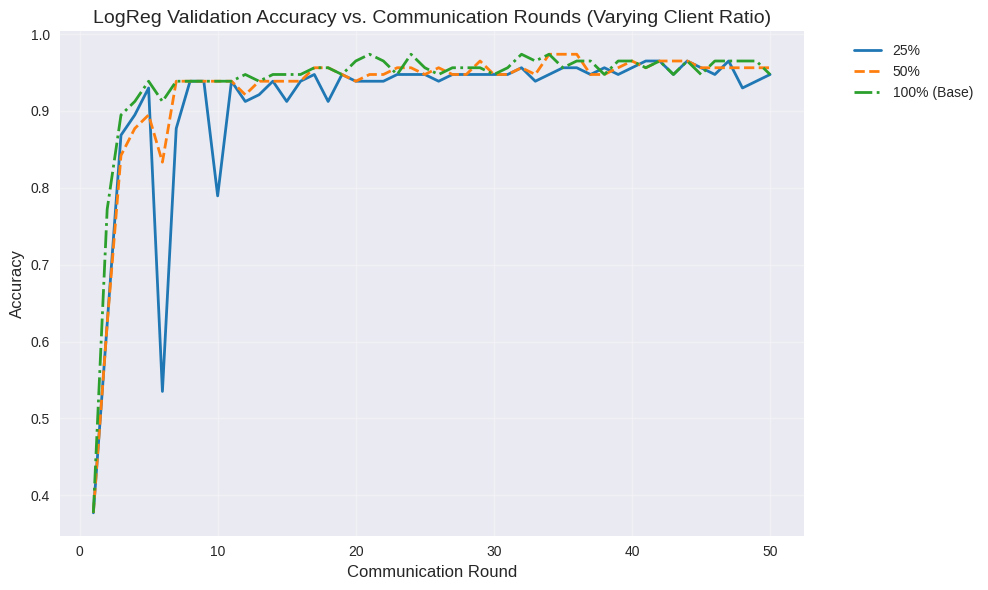

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/logreg_ratio_costs.png


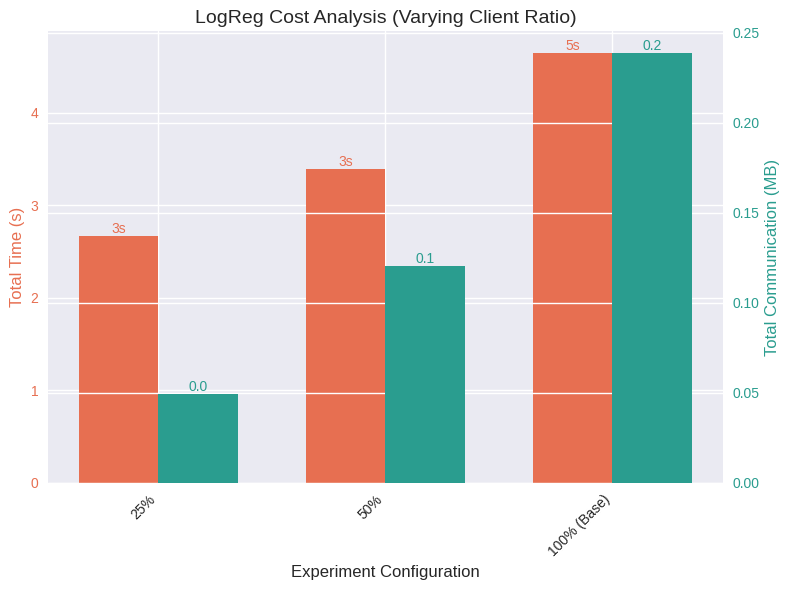

In [11]:
# MLP Client Ratio Analysis
plot_evolution_metric(logreg_ratio_experiments, metric='accuracy', 
                      title='LogReg Validation Accuracy vs. Communication Rounds (Varying Client Ratio)', 
                      filename='logreg_ratio_accuracy.png')

plot_cost_summary(logreg_ratio_experiments, 
                  title='LogReg Cost Analysis (Varying Client Ratio)', 
                  filename='logreg_ratio_costs.png')